Practical 4
(Due Week 10, Monday, 11:59pm)

# 1 Generating Random Training Points

Similarly as in the lecture, using numpy.random, generate 1000 random
linear looking points and use it as the training set X_b (see Slide No. 51 of
Week_4’s lecture).

In [1]:
import numpy as np
import pandas as pd
# For reproducibility
np.random.seed(42)

# Create linear-looking data
X =  2 * np.random.rand(1000, 1)
y =  4 + 3 * X + np.random.randn(1000, 1)

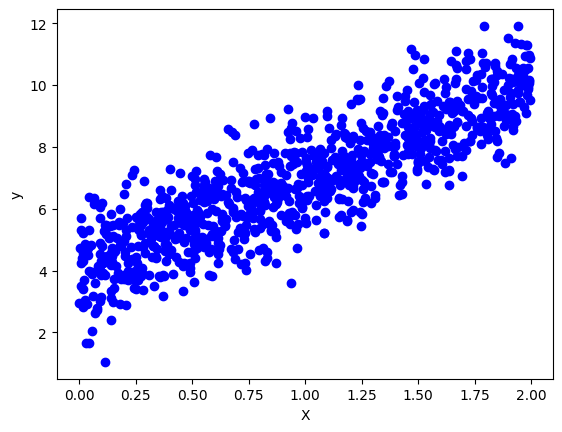

In [2]:
# Plot the data
import matplotlib.pyplot as plt

plt.ylabel('y')
plt.xlabel('X')
plt.plot(X, y, 'bo')
plt.show()

In [3]:
len(X)

1000

# 2 Visualising Gradient Descent

1. For the given randomly generated linear looking data "X_b" and using the
Gradient Descent (GD) step formula:
Θ
next step = Θ − η∇ΘMSE(Θ)
(and implemented in numpy as in Slide No. 76 of Week_4’s lecture) graph
the first 10 steps of GD for each three different learning rates: η = 0.02, η =
0.1 and η = 0.5 (note: make sure to also include your training set data in the
plots as well).


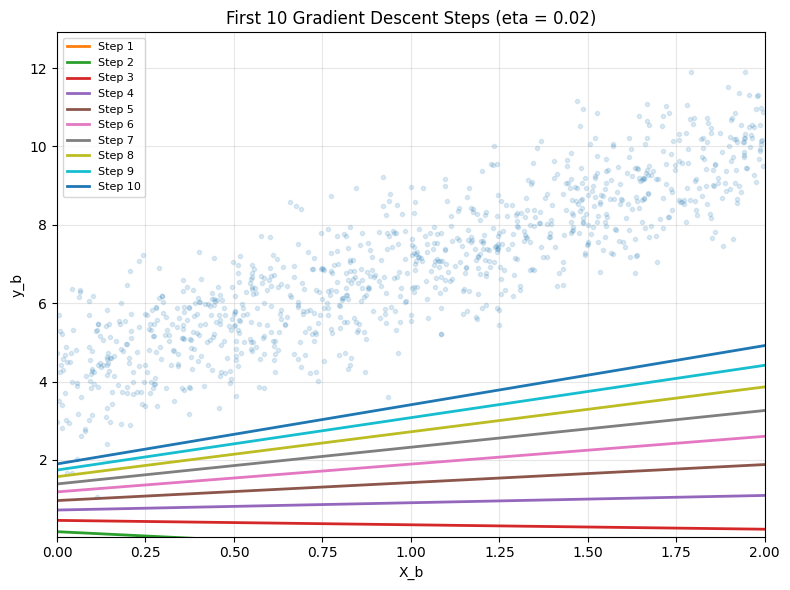

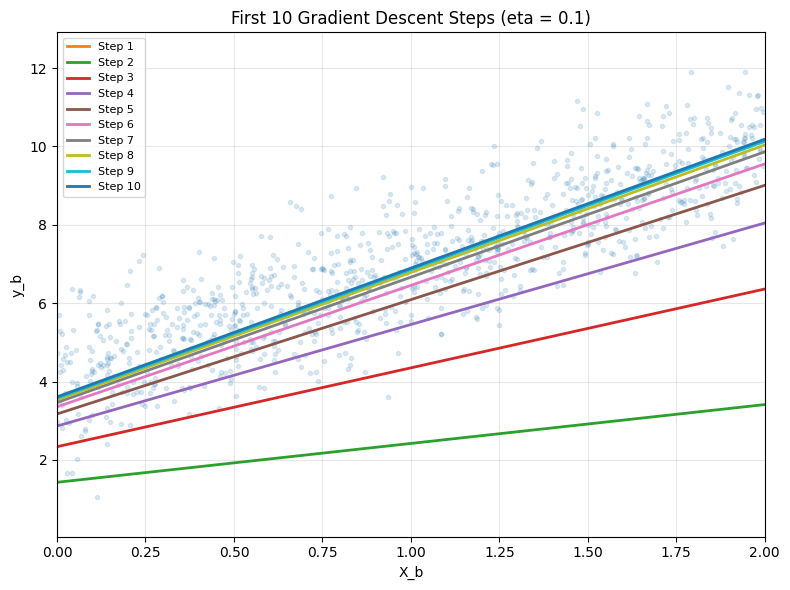

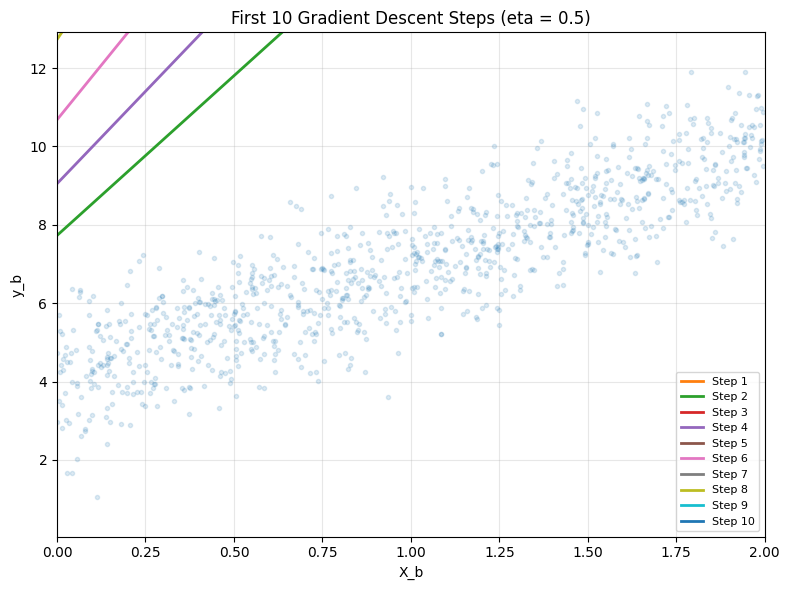

Saved files:
gd_steps_eta_0_02.png
gd_steps_eta_0_1.png
gd_steps_eta_0_5.png


In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Add bias term
X_b = X.copy()
y_b = y.copy()
m = len(X_b)

X_with_bias = np.c_[np.ones((m, 1)), X_b]

# Initial theta for the learning-rate
initial_theta = np.random.randn(2, 1)

# Learning rates to compare
etas = [0.02, 0.1, 0.5]
n_steps = 10

# Points for drawing regression lines
X_line = np.array([[0], [2]])
X_line_with_bias = np.c_[np.ones((2, 1)), X_line]

saved_files = []

for eta in etas:
    theta = initial_theta.copy()

    plt.figure(figsize=(8, 6))
    plt.plot(X_b, y_b, ".", alpha=0.15)

    # Plot first 10 GD steps
    for step in range(n_steps):
        y_predict_line = X_line_with_bias.dot(theta)
        plt.plot(X_line, y_predict_line, linewidth=2, label=f"Step {step + 1}" if step < 10 else None)

        gradients = (2 / m) * X_with_bias.T.dot(X_with_bias.dot(theta) - y_b)
        theta = theta - eta * gradients

    plt.title(f"First 10 Gradient Descent Steps (eta = {eta})")
    plt.xlabel("X_b")
    plt.ylabel("y_b")
    plt.xlim(0, 2)
    plt.ylim(y_b.min() - 1, y_b.max() + 1)
    plt.legend(loc="best", fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out_path = f"gd_steps_eta_{str(eta).replace('.', '_')}.png"
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    saved_files.append(out_path)
    plt.show()
    plt.close()

print("Saved files:")
for f in saved_files:
    print(f)

# 3 Using the LinearRegression Class

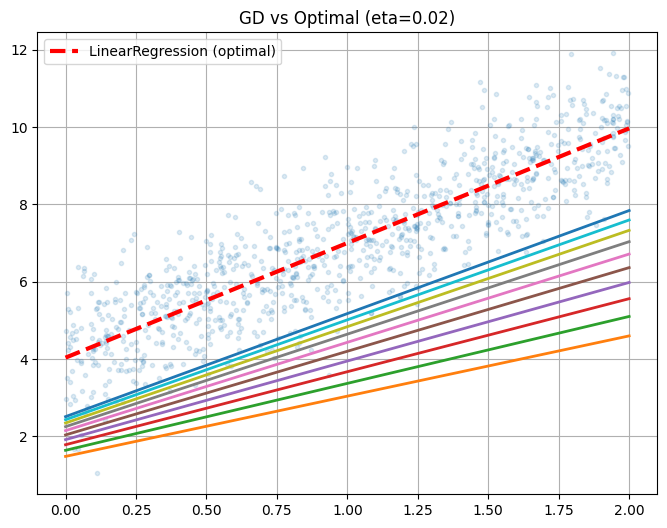

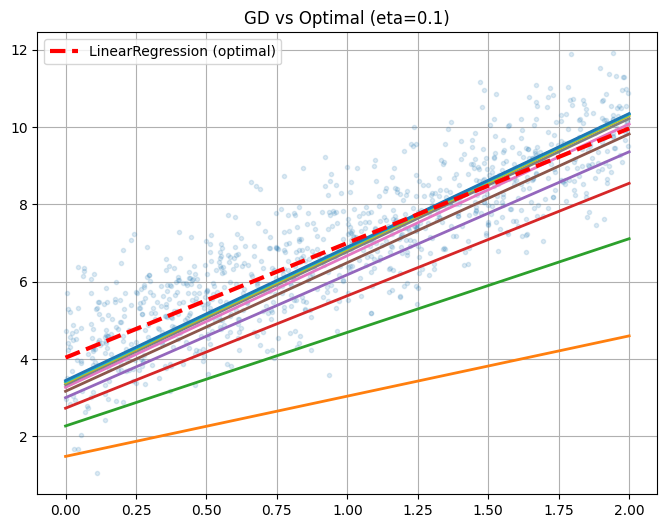

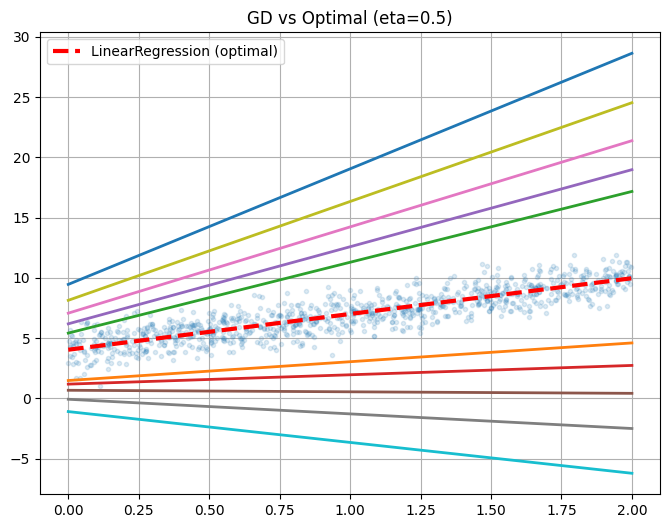

In [17]:
from sklearn.linear_model import LinearRegression

m = len(X)
X_b = np.c_[np.ones((m, 1)), X]

# Fit Linear Regression (optimal solution)
lin_reg = LinearRegression()
lin_reg.fit(X, y)

theta_best = np.r_[lin_reg.intercept_.reshape(-1,1), lin_reg.coef_.T]

# GD setup
initial_theta = np.random.randn(2, 1)
etas = [0.02, 0.1, 0.5]
n_steps = 10

X_line = np.array([[0], [2]])
X_line_b = np.c_[np.ones((2, 1)), X_line]

for eta in etas:
    theta = initial_theta.copy()

    plt.figure(figsize=(8,6))
    plt.plot(X, y, ".", alpha=0.15)

    # GD iterations
    for step in range(n_steps):
        y_pred = X_line_b.dot(theta)
        plt.plot(X_line, y_pred, linewidth=2)

        gradients = (2/m) * X_b.T.dot(X_b.dot(theta) - y)
        theta = theta - eta * gradients

    # Optimal line
    y_best = X_line_b.dot(theta_best)
    plt.plot(X_line, y_best, "r--", linewidth=3, label="LinearRegression (optimal)")

    plt.title(f"GD vs Optimal (eta={eta})")
    plt.legend()
    plt.grid(True)
    plt.show()

# 4 SGD Learning Schedules
1. In the implementation of SGD in Week_4’s lecture (see Slide No. 84 of the
lecture notes), try and implement SGD for at least three different learning
schedules and compare the results with using scikit-learn’s SGDRegressor.

LinearRegression reference theta:
[[4.03544211]
 [2.96711718]]
LinearRegression MSE: 0.9302383305218237

Custom SGD results
Constant:
Theta:
[[3.97563091]
 [2.90999877]]
MSE: 0.9447181144095159

Time-based decay:
Theta:
[[4.03612296]
 [2.96812067]]
MSE: 0.9302414308824482

Inverse scaling:
Theta:
[[4.0361727 ]
 [2.96745639]]
MSE: 0.9302394986124363

scikit-learn SGDRegressor:
[[4.0142511 ]
 [2.98436221]]
MSE: 0.9303533012852993



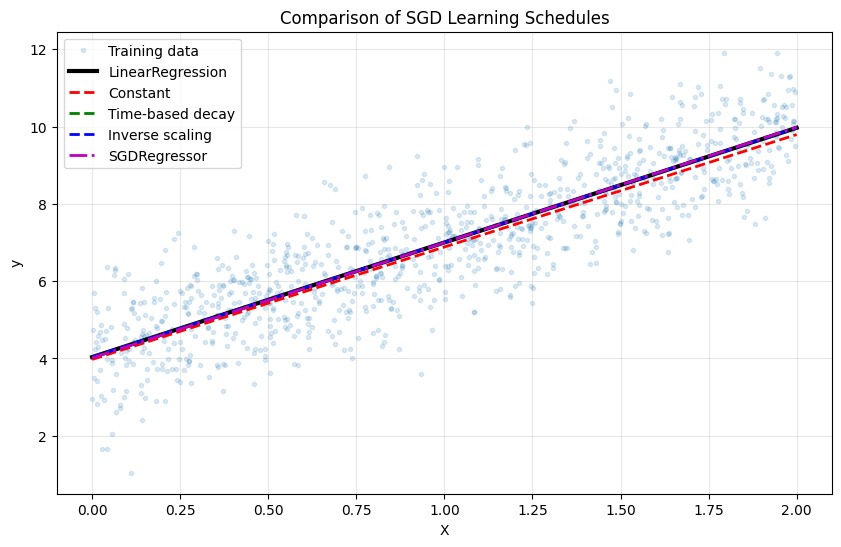

In [18]:
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_squared_error


m = len(X)
X_b = np.c_[np.ones((m, 1)), X]   # add bias column

# -----------------------------
# 2. Reference solution using LinearRegression
# -----------------------------
lin_reg = LinearRegression()
lin_reg.fit(X, y)

theta_ref = np.array([[lin_reg.intercept_[0]], [lin_reg.coef_[0][0]]])
y_pred_ref = lin_reg.predict(X)
mse_ref = mean_squared_error(y, y_pred_ref)

print("LinearRegression reference theta:")
print(theta_ref)
print("LinearRegression MSE:", mse_ref)
print()

# -----------------------------
# 3. Learning schedules
# -----------------------------
def constant_schedule(t, eta0=0.1):
    return eta0

def time_based_schedule(t, eta0=0.1, decay=0.01):
    return eta0 / (1 + decay * t)

def inverse_scaling_schedule(t, eta0=0.1, power=0.5):
    return eta0 / (t + 1) ** power

# -----------------------------
# 4. Custom SGD implementation
# -----------------------------
def custom_sgd(X_b, y, n_epochs=50, schedule_fn=None, random_state=42):
    rng = np.random.RandomState(random_state)
    m, n = X_b.shape
    theta = rng.randn(n, 1)
    theta_path = [theta.copy()]
    t = 0

    for epoch in range(n_epochs):
        shuffled_indices = rng.permutation(m)
        X_b_shuffled = X_b[shuffled_indices]
        y_shuffled = y[shuffled_indices]

        for i in range(m):
            xi = X_b_shuffled[i:i+1]          # shape (1, n)
            yi = y_shuffled[i:i+1]            # shape (1, 1)

            gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
            eta = schedule_fn(t)
            theta = theta - eta * gradients

            theta_path.append(theta.copy())
            t += 1

    return theta, theta_path

# -----------------------------
# 5. Run custom SGD with 3 schedules
# -----------------------------
results = {}

schedules = {
    "Constant": lambda t: constant_schedule(t, eta0=0.02),
    "Time-based decay": lambda t: time_based_schedule(t, eta0=0.1, decay=0.01),
    "Inverse scaling": lambda t: inverse_scaling_schedule(t, eta0=0.1, power=0.5),
}

for name, sched in schedules.items():
    theta, theta_path = custom_sgd(X_b, y, n_epochs=50, schedule_fn=sched, random_state=42)
    y_pred = X_b.dot(theta)
    mse = mean_squared_error(y, y_pred)

    results[name] = {
        "theta": theta,
        "mse": mse,
        "path": theta_path
    }

# -----------------------------
# 6. Compare with SGDRegressor
# -----------------------------
sgd_reg = SGDRegressor(
    max_iter=1000,
    tol=1e-6,
    penalty=None,
    eta0=0.1,
    learning_rate="invscaling",
    power_t=0.5,
    random_state=42
)

sgd_reg.fit(X, y.ravel())

theta_sgd_sklearn = np.array([[sgd_reg.intercept_[0]], [sgd_reg.coef_[0]]])
y_pred_sgd_sklearn = sgd_reg.predict(X)
mse_sgd_sklearn = mean_squared_error(y, y_pred_sgd_sklearn)

# -----------------------------
# 7. Print results
# -----------------------------
print("Custom SGD results")
for name, res in results.items():
    print(f"{name}:")
    print("Theta:")
    print(res["theta"])
    print("MSE:", res["mse"])
    print()

print("scikit-learn SGDRegressor:")
print(theta_sgd_sklearn)
print("MSE:", mse_sgd_sklearn)
print()

# -----------------------------
# 8. Plot final regression lines
# -----------------------------
X_line = np.array([[0], [2]])
X_line_b = np.c_[np.ones((2, 1)), X_line]

plt.figure(figsize=(10, 6))
plt.plot(X, y, ".", alpha=0.15, label="Training data")

# LinearRegression reference line
plt.plot(X_line, X_line_b.dot(theta_ref), "k-", linewidth=3, label="LinearRegression")

# Custom SGD lines
styles = ["r--", "g--", "b--"]
for (name, res), style in zip(results.items(), styles):
    plt.plot(X_line, X_line_b.dot(res["theta"]), style, linewidth=2, label=name)

# SGDRegressor line
plt.plot(X_line, X_line_b.dot(theta_sgd_sklearn), "m-.", linewidth=2, label="SGDRegressor")

plt.xlabel("X")
plt.ylabel("y")
plt.title("Comparison of SGD Learning Schedules")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5 Implementing Mini-batch Gradient Descent
1. Implement mini-batch gradient descent (Hint: modify the code in Slide No.
84 of Week_4’s lecture).


Theta from Mini-batch GD:
[[4.03751206]
 [2.96707678]]

Theta from LinearRegression:
[[4.03544211]
 [2.96711718]]

Mini-batch GD MSE: 0.9302424532620546
LinearRegression MSE: 0.9302383305218237


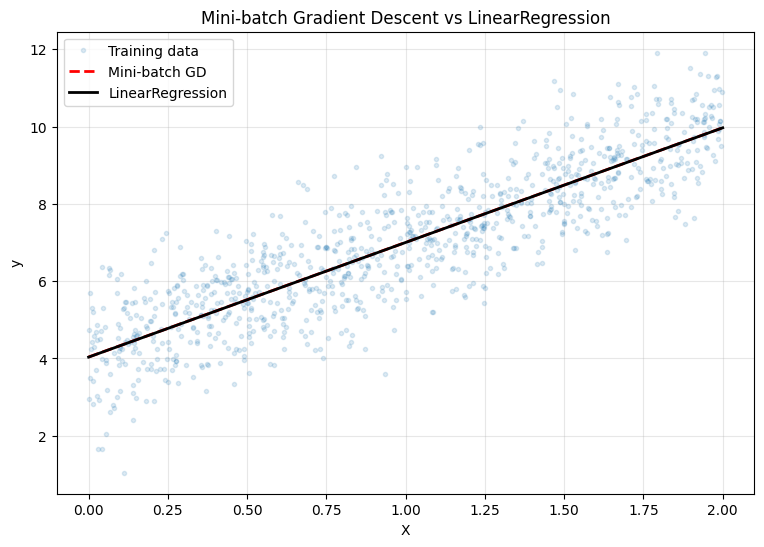

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

m = len(X)
X_b = np.c_[np.ones((m, 1)), X]   # add bias term

# -----------------------------
# 2. Learning schedule
# -----------------------------
def learning_schedule(t, t0=5, t1=50):
    return t0 / (t + t1)

# -----------------------------
# 3. Mini-batch Gradient Descent
# -----------------------------
n_epochs = 50
minibatch_size = 20
theta = np.random.randn(2, 1)
t = 0

theta_path_mgd = []

for epoch in range(n_epochs):
    shuffled_indices = np.random.permutation(m)
    X_b_shuffled = X_b[shuffled_indices]
    y_shuffled = y[shuffled_indices]

    for i in range(0, m, minibatch_size):
        xi = X_b_shuffled[i:i + minibatch_size]
        yi = y_shuffled[i:i + minibatch_size]

        gradients = (2 / len(xi)) * xi.T.dot(xi.dot(theta) - yi)
        eta = learning_schedule(t)
        theta = theta - eta * gradients

        theta_path_mgd.append(theta.copy())
        t += 1

print("Theta from Mini-batch GD:")
print(theta)

# -----------------------------
# 4. Compare with LinearRegression
# -----------------------------
lin_reg = LinearRegression()
lin_reg.fit(X, y)

theta_lin = np.array([[lin_reg.intercept_[0]], [lin_reg.coef_[0][0]]])

print("\nTheta from LinearRegression:")
print(theta_lin)

# -----------------------------
# 5. Compute MSE
# -----------------------------
y_pred_mgd = X_b.dot(theta)
y_pred_lin = lin_reg.predict(X)

mse_mgd = mean_squared_error(y, y_pred_mgd)
mse_lin = mean_squared_error(y, y_pred_lin)

print("\nMini-batch GD MSE:", mse_mgd)
print("LinearRegression MSE:", mse_lin)

# -----------------------------
# 6. Plot training data and regression lines
# -----------------------------
X_line = np.array([[0], [2]])
X_line_b = np.c_[np.ones((2, 1)), X_line]

plt.figure(figsize=(9, 6))
plt.plot(X, y, ".", alpha=0.15, label="Training data")
plt.plot(X_line, X_line_b.dot(theta), "r--", linewidth=2, label="Mini-batch GD")
plt.plot(X_line, X_line_b.dot(theta_lin), "k-", linewidth=2, label="LinearRegression")

plt.xlabel("X")
plt.ylabel("y")
plt.title("Mini-batch Gradient Descent vs LinearRegression")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 6 Plotting Regression Predictions
1. Using the python code in Slide No. 100 of Week_4’s lecture, write a code
to plot the predicted y values to achieve similar scatter plot as in Slide No.
100 (Hint: I’ve used 0.1 increments on the x-axis).


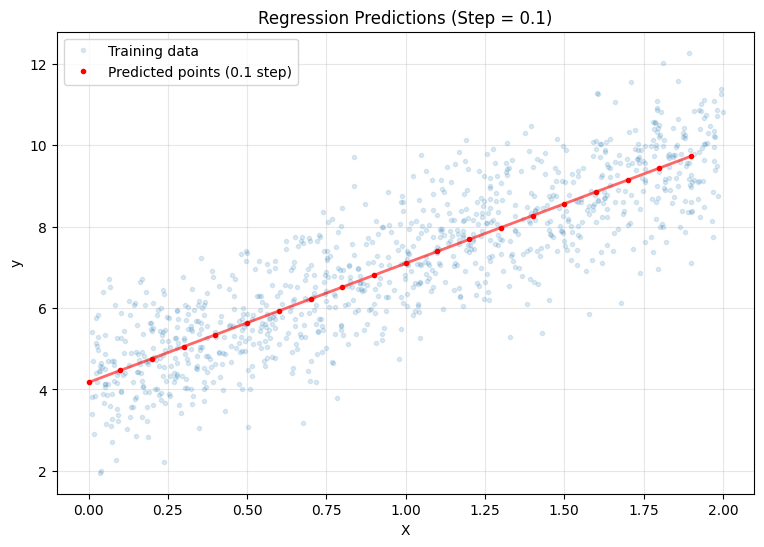

In [21]:
# -----------------------------
# 2. Train model
# -----------------------------
lin_reg = LinearRegression()
lin_reg.fit(X, y)

# -----------------------------
# 3. Create evenly spaced X values (step = 0.1)
# -----------------------------
X_new = np.arange(0, 2, 0.1).reshape(-1, 1)

# -----------------------------
# 4. Predict y values
# -----------------------------
y_pred = lin_reg.predict(X_new)

# -----------------------------
# 5. Plot
# -----------------------------
plt.figure(figsize=(9, 6))

# original training data
plt.plot(X, y, ".", alpha=0.15, label="Training data")

# predicted points (scatter)
plt.plot(X_new, y_pred, "r.", label="Predicted points (0.1 step)")

# optional: connect predictions as a line
plt.plot(X_new, y_pred, "r-", linewidth=2, alpha=0.6)

plt.xlabel("X")
plt.ylabel("y")
plt.title("Regression Predictions (Step = 0.1)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

# 7 Plotting Regression Probabilities
1. In Slide No. 120, we had a code for training the iris dataset under the
logistic regression model. Plot the model’s obtained probabilities as in the
image on Slide No. 121 of Week_4’s lecture.
(Hint: use LogisticRegression.predict_proba(X_points)
to return the probabilities of an evenly spaced interval of point X_points.)

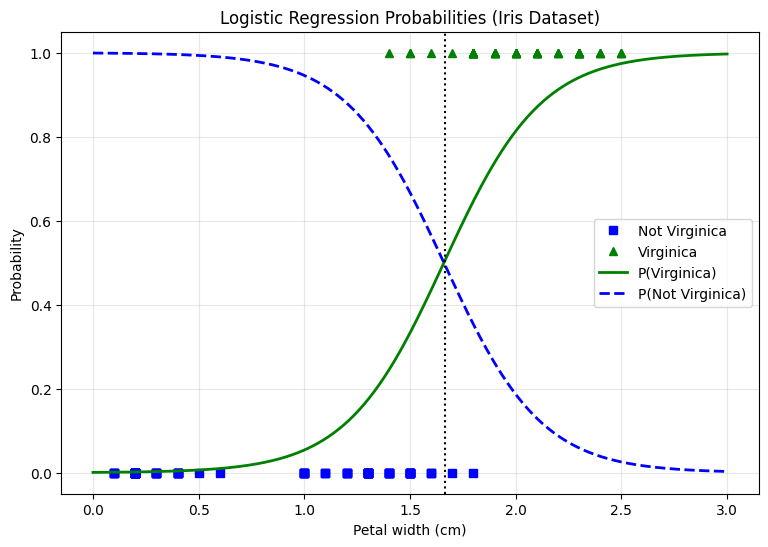

In [22]:
from sklearn import datasets
from sklearn.linear_model import LogisticRegression

# -----------------------------
# 1. Load Iris dataset
# -----------------------------
iris = datasets.load_iris()

# Use ONE feature (like in lecture)
# Typically petal width (column index = 3)
X = iris["data"][:, 3:]   # shape (150, 1)

# Binary classification: Virginica or not
y = (iris["target"] == 2).astype(int)

# -----------------------------
# 2. Train Logistic Regression
# -----------------------------
log_reg = LogisticRegression()
log_reg.fit(X, y)

# -----------------------------
# 3. Create evenly spaced inputs
# -----------------------------
X_new = np.linspace(0, 3, 500).reshape(-1, 1)

# -----------------------------
# 4. Get probabilities
# -----------------------------
y_proba = log_reg.predict_proba(X_new)

# -----------------------------
# 5. Plot
# -----------------------------
plt.figure(figsize=(9, 6))

# Training points
plt.plot(X[y == 0], y[y == 0], "bs", label="Not Virginica")
plt.plot(X[y == 1], y[y == 1], "g^", label="Virginica")

# Probability curves
plt.plot(X_new, y_proba[:, 1], "g-", linewidth=2, label="P(Virginica)")
plt.plot(X_new, y_proba[:, 0], "b--", linewidth=2, label="P(Not Virginica)")

# Decision boundary (optional)
decision_boundary = X_new[y_proba[:, 1] >= 0.5][0]
plt.axvline(x=decision_boundary, color="k", linestyle=":")

plt.xlabel("Petal width (cm)")
plt.ylabel("Probability")
plt.title("Logistic Regression Probabilities (Iris Dataset)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()